# Function 5 Analysis - Week 11

1. **Function description (unchanged):**  
You're tasked with optimising a four-variable black-box function that represents the yield of a chemical process in a factory. The function is typically unimodal, with a single peak where yield is maximised. Your goal is to find the optimal combination of chemical inputs that delivers the highest possible yield, using systematic exploration and optimisation methods.

2. **Week 10 evaluated point:** `(0.261027, 1.000000, 1.000000, 1.000000)` returned **≈4460.2266**, so it is a **new maximum**.

3. **Analysis of last point:** The monotonic ridge strategy worked again; keeping `x2/x3/x4` at the ceiling while tuning low `x1` continues to improve yield.

4. **Why we chose last week’s point (from Week 10 logic):** Week 10 enforced a monotonic ridge rule (`x2*x3*x4` must exceed the incumbent product), so the selected point stayed fully forward on the high-yield ridge instead of drifting backward.

5. **Recommendation for Week 12 (and why):** For this round, use a direct manual probe with `x2=x3=x4=1` and set `x1=0.27` to test whether the upward `x1` trend continues.


## Loading and Displaying the Data

We load the inputs and outputs for function 5. Week 10 `(0.261027, 1.000000, 1.000000, 1.000000)` returned **≈4460.2266** and has been added to the dataset.


In [65]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_5")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1–8 new points
X_new_point_week_1 = np.array([[0.191447, 0.846480, 0.879484, 0.878516]])
y_new_point_week_1 = np.array([1086.3644542213872])
X_new_point_week_2 = np.array([[0.202624, 0.849188, 0.971974, 0.920186]])
y_new_point_week_2 = np.array([1935.0092608386958])
X_new_point_week_3 = np.array([[0.203491, 0.849529, 0.982723, 0.925116]])
y_new_point_week_3 = np.array([2066.674475985541])
X_new_point_week_4 = np.array([[0.206189, 0.850311, 1.000000, 0.936243]])
y_new_point_week_4 = np.array([2323.4365797217065])
X_new_point_week_5 = np.array([[0.218976, 0.853432, 1.000000, 0.979950]])
y_new_point_week_5 = np.array([2748.829971152165])
X_new_point_week_6 = np.array([[0.225152, 0.855580, 1.000000, 1.000000]])
y_new_point_week_6 = np.array([2981.55176998145])
X_new_point_week_7 = np.array([[0.242550, 0.875768, 1.000000, 1.000000]])
y_new_point_week_7 = np.array([3136.42])
X_new_point_week_8 = np.array([[0.241596, 0.899190, 0.999688, 1.000000]])
y_new_point_week_8 = np.array([3327.429213141313])
X_new_point_week_9 = np.array([[0.259760, 0.982671, 1.000000, 1.000000]])
y_new_point_week_9 = np.array([4228.11736979434])
X_new_point_week_10 = np.array([[0.261027, 1.000000, 1.000000, 1.000000]])
y_new_point_week_10 = np.array([4460.226648000525])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
    X_new_point_week_7,
    X_new_point_week_8,
    X_new_point_week_9,
    X_new_point_week_10,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
    y_new_point_week_7,
    y_new_point_week_8,
    y_new_point_week_9,
    y_new_point_week_10,
])

df = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
df_sorted["x_avg"] = df_sorted[["x1", "x2", "x3", "x4"]].mean(axis=1)
display(df_sorted)


,x1,x2,x3,x4,y
0,0.191447,0.038193,0.607418,0.414584,64.443440
1,0.758653,0.536518,0.656000,0.360342,18.301380
2,0.438350,0.804340,0.210245,0.151295,0.112940
3,0.706051,0.534192,0.264243,0.482088,4.210898
4,0.836478,0.193610,0.663893,0.785649,258.370525
5,0.683432,0.118663,0.829046,0.567577,78.434389
6,0.553621,0.667350,0.323806,0.814870,57.571537
7,0.352356,0.322242,0.116979,0.473113,109.571876
8,0.153786,0.729382,0.422598,0.443074,8.847992
9,0.463442,0.630025,0.107906,0.957644,233.223610


df sorted by y


,x1,x2,x3,x4,y,x_avg
0,0.261027,1.000000,1.000000,1.000000,4460.226648,0.815257
1,0.259760,0.982671,1.000000,1.000000,4228.117370,0.810608
2,0.241596,0.899190,0.999688,1.000000,3327.429213,0.785119
3,0.242550,0.875768,1.000000,1.000000,3136.420000,0.779579
4,0.225152,0.855580,1.000000,1.000000,2981.551770,0.770183
5,0.218976,0.853432,1.000000,0.979950,2748.829971,0.763090
6,0.206189,0.850311,1.000000,0.936243,2323.436580,0.748186
7,0.203491,0.849529,0.982723,0.925116,2066.674476,0.740215
8,0.202624,0.849188,0.971974,0.920186,1935.009261,0.735993
9,0.224189,0.846480,0.879484,0.878516,1088.859618,0.707167


## Weekly Optimization Progress Summary

Overview of all 10 weeks of Bayesian Optimization, showing which evaluations achieved new maximum values.

- **Week 10 update:** `(0.261027, 1.000000, 1.000000, 1.000000)` → **≈4460.2266** (**new maximum**).


In [66]:
# Build weekly progress dataframe from available week variables (auto-detect)
weekly_X, weekly_y = [], []
week_idx = 1
while f'X_new_point_week_{week_idx}' in globals() and f'y_new_point_week_{week_idx}' in globals():
    weekly_X.append(globals()[f'X_new_point_week_{week_idx}'])
    weekly_y.append(globals()[f'y_new_point_week_{week_idx}'])
    week_idx += 1

df_weeks = pd.DataFrame({
    'Week': range(1, len(weekly_X) + 1),
    'x1': [x[0, 0] for x in weekly_X],
    'x2': [x[0, 1] for x in weekly_X],
    'x3': [x[0, 2] for x in weekly_X],
    'x4': [x[0, 3] for x in weekly_X],
    'y': [y[0] for y in weekly_y]
})

# Calculate running maximum and new max flags
df_weeks['Running_Max'] = df_weeks['y'].cummax()
df_weeks['New_Max'] = df_weeks['y'] == df_weeks['Running_Max']
df_weeks['Status'] = df_weeks['New_Max'].map({True: '✓ NEW MAX', False: '✗'})
df_weeks['Prev_Max'] = df_weeks['Running_Max'].shift(1).fillna(0)
df_weeks['Improvement'] = np.where(df_weeks['New_Max'], df_weeks['y'] - df_weeks['Prev_Max'], np.nan)

# Display table
print('=' * 110)
print('WEEKLY OPTIMIZATION PROGRESS')
print('=' * 110)
df_display = df_weeks[['Week', 'x1', 'x2', 'x3', 'x4', 'y', 'Running_Max', 'Status', 'Improvement']].copy()
df_display['Improvement'] = df_display['Improvement'].apply(lambda x: f'+{x:.2f}' if pd.notna(x) else '-')
display(df_display)

# Summary statistics
new_max_weeks = df_weeks[df_weeks['New_Max']]['Week'].tolist()
print(f"\n📊 Summary: {df_weeks['New_Max'].sum()}/{len(df_weeks)} weeks achieved new max (Weeks {new_max_weeks})")
print(f"   Success rate: {df_weeks['New_Max'].sum() / len(df_weeks) * 100:.1f}% | Final best: {df_weeks['y'].max():.2f} | Improvement: {df_weeks['y'].max() / df_weeks['y'].iloc[0]:.1f}x from Week 1")

WEEKLY OPTIMIZATION PROGRESS


,Week,x1,x2,x3,x4,y,Running_Max,Status,Improvement
0,1,0.191447,0.846480,0.879484,0.878516,1086.364454,1086.364454,✓ NEW MAX,+1086.36
1,2,0.202624,0.849188,0.971974,0.920186,1935.009261,1935.009261,✓ NEW MAX,+848.64
2,3,0.203491,0.849529,0.982723,0.925116,2066.674476,2066.674476,✓ NEW MAX,+131.67
3,4,0.206189,0.850311,1.000000,0.936243,2323.436580,2323.436580,✓ NEW MAX,+256.76
4,5,0.218976,0.853432,1.000000,0.979950,2748.829971,2748.829971,✓ NEW MAX,+425.39
5,6,0.225152,0.855580,1.000000,1.000000,2981.551770,2981.551770,✓ NEW MAX,+232.72
6,7,0.242550,0.875768,1.000000,1.000000,3136.420000,3136.420000,✓ NEW MAX,+154.87
7,8,0.241596,0.899190,0.999688,1.000000,3327.429213,3327.429213,✓ NEW MAX,+191.01
8,9,0.259760,0.982671,1.000000,1.000000,4228.117370,4228.117370,✓ NEW MAX,+900.69
9,10,0.261027,1.000000,1.000000,1.000000,4460.226648,4460.226648,✓ NEW MAX,+232.11



📊 Summary: 10/10 weeks achieved new max (Weeks [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
   Success rate: 100.0% | Final best: 4460.23 | Improvement: 4.1x from Week 1


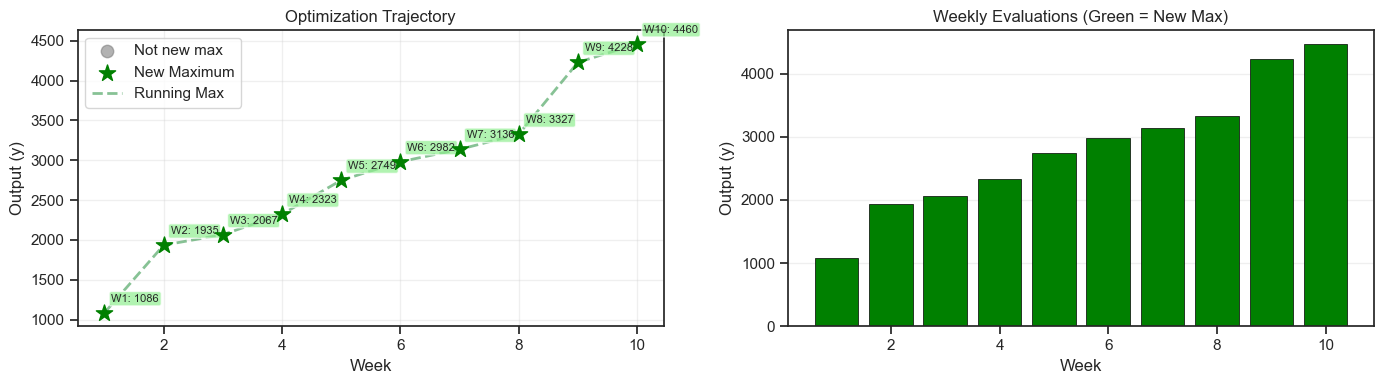

In [67]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

weeks = df_weeks['Week']
y_vals = df_weeks['y']
new_max_mask = df_weeks['New_Max']

# Left plot: Scatter with running max line
ax1.scatter(weeks[~new_max_mask], y_vals[~new_max_mask], color='gray', s=80, alpha=0.6, label='Not new max')
ax1.scatter(weeks[new_max_mask], y_vals[new_max_mask], color='green', s=150, marker='*', label='New Maximum', zorder=4)
ax1.plot(weeks, df_weeks['Running_Max'], 'g--', alpha=0.7, lw=2, label='Running Max')
for _, row in df_weeks[new_max_mask].iterrows():
    ax1.annotate(f"W{int(row['Week'])}: {row['y']:.0f}", xy=(row['Week'], row['y']), 
                 xytext=(5, 8), textcoords='offset points', fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.2', fc='lightgreen', alpha=0.7))
ax1.set_xlabel('Week'); ax1.set_ylabel('Output (y)')
ax1.set_title('Optimization Trajectory'); ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.3)

# Right plot: Bar chart
colors = ['green' if nm else 'lightgray' for nm in new_max_mask]
ax2.bar(weeks, y_vals, color=colors, edgecolor='black', lw=0.5)
ax2.axhline(y=0, color='black', lw=0.5)
ax2.set_xlabel('Week'); ax2.set_ylabel('Output (y)')
ax2.set_title('Weekly Evaluations (Green = New Max)'); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**Week 10 Result:**
- `(0.261027, 1.000000, 1.000000, 1.000000)` yielded **≈4460.23 — new maximum!**
- Pushing the high-product corner further worked again.
- The ridge is still climbing (no clear plateau yet).

**The pattern remains clear:**
- Keep `x1` low (around 0.24–0.27).
- Keep `x2` very high (at 1.0).
- Keep `x3` and `x4` at 1.0.


## Product feature: x2·x3·x4

The strongest signal comes from the simple product `x234_prod = x2 * x3 * x4`. We focus on this single feature and visualize it against y; no other derived features or candidate selection logic are needed.


In [68]:
# Focus on the single product feature

# Product of x2-x4 (multiplicative interaction)
df_analysis = df.copy()
df_analysis["x234_prod"] = df_analysis["x2"] * df_analysis["x3"] * df_analysis["x4"]

# Correlation of x234_prod with y
correlations = df_analysis[["x234_prod", "y"]].corr()["y"]
print("Correlation (x234_prod, y):")
print("=" * 40)
print(f"x234_prod: {correlations['x234_prod']:.4f}")


Correlation (x234_prod, y):
x234_prod: 0.9394


## Visualization of x234_prod

We visualize the relationship between `x234_prod` (product of x2, x3, x4) and y, which shows the highest correlation (≈0.93) among all features.


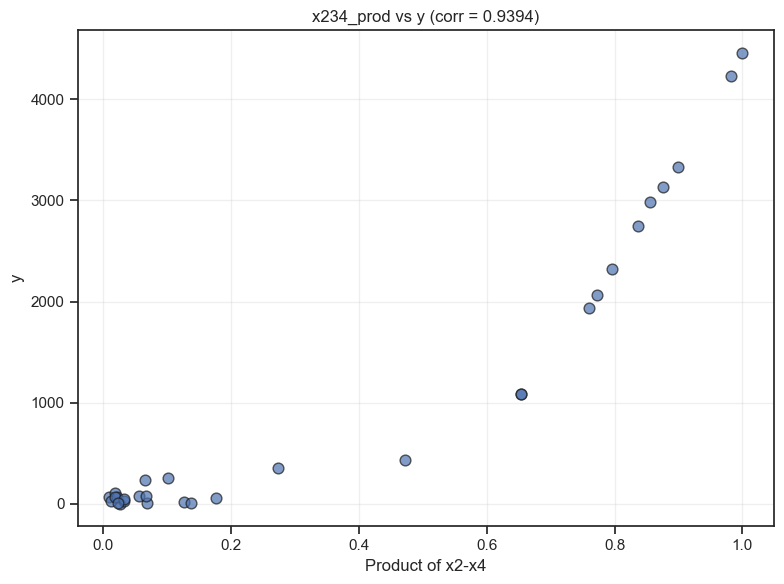

In [69]:
# Visualize x234_prod vs y
plt.figure(figsize=(8, 6))
plt.scatter(df_analysis["x234_prod"], df_analysis["y"], alpha=0.7, edgecolors='k', s=60)
plt.xlabel("Product of x2-x4")
plt.ylabel("y")
plt.title(f"x234_prod vs y (corr = {correlations['x234_prod']:.4f})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Gain decomposition: x1 vs x2*x3*x4

To reduce dimensionality and explain the large jumps, we decompose week-to-week gains using two factors:
- `x1` (fine tuner)
- `x234_prod = x2*x3*x4` (ridge/amplifier)

We fit a compact 2-factor interaction model and attribute each transition's predicted gain into:
1. contribution from changing `x1`
2. contribution from changing `x234_prod`

This helps answer whether the +800 jumps were mostly product-driven, x1-driven, or mixed.


In [70]:
# Two-factor gain decomposition: x1 vs x234_prod
# (uses df_weeks from the weekly progress section)
analysis_weeks = df_weeks[['Week', 'x1', 'x2', 'x3', 'x4', 'y']].copy()
analysis_weeks['x234_prod'] = analysis_weeks['x2'] * analysis_weeks['x3'] * analysis_weeks['x4']

# Build transition table
# We track gains in two ways:
# 1) gain_from_prev (Week 1 uses baseline 0)
# 2) decomposition transitions (Week 2+ only, needs previous x1/prod)
trans_all = analysis_weeks.copy()
trans_all['y_prev'] = trans_all['y'].shift(1).fillna(0.0)
trans_all['gain_from_prev'] = trans_all['y'] - trans_all['y_prev']

trans = analysis_weeks.copy()
# Synthetic Week-0 baseline for decomposition so Week 1 is included:
# (x1_prev, prod_prev, y_prev) = (0, 0, 0)
trans['x1_prev'] = trans['x1'].shift(1).fillna(0.0)
trans['prod_prev'] = trans['x234_prod'].shift(1).fillna(0.0)
trans['y_prev'] = trans['y'].shift(1).fillna(0.0)
trans['dx1'] = trans['x1'] - trans['x1_prev']
trans['dprod'] = trans['x234_prod'] - trans['prod_prev']
trans['dy'] = trans['y'] - trans['y_prev']

# Fit compact level model: y ~ 1 + x1 + prod + x1*prod
A = np.column_stack([
    np.ones(len(analysis_weeks)),
    analysis_weeks['x1'].values,
    analysis_weeks['x234_prod'].values,
    (analysis_weeks['x1'] * analysis_weeks['x234_prod']).values,
])
beta = np.linalg.lstsq(A, analysis_weeks['y'].values, rcond=None)[0]
b0, b1, b2, b3 = beta

# Midpoint decomposition per transition
x1_mid = 0.5 * (trans['x1'].values + trans['x1_prev'].values)
prod_mid = 0.5 * (trans['x234_prod'].values + trans['prod_prev'].values)

trans['contrib_x1'] = (b1 + b3 * prod_mid) * trans['dx1'].values
trans['contrib_prod'] = (b2 + b3 * x1_mid) * trans['dprod'].values
trans['pred_dy'] = trans['contrib_x1'] + trans['contrib_prod']
trans['residual'] = trans['dy'] - trans['pred_dy']

# Focus on large gain events (now fully aligned with decomposition)
big_gain_all = trans_all[trans_all['gain_from_prev'] >= 800].copy()
big_gain = trans[trans['dy'] >= 800].copy()

print('=' * 70)
print('TWO-FACTOR GAIN DECOMPOSITION (x1 vs x2*x3*x4)')
print('=' * 70)
print(f"Model: y ≈ {b0:.2f} + ({b1:.2f})*x1 + ({b2:.2f})*prod + ({b3:.2f})*x1*prod")
print(f"Gain events incl. Week 1 baseline (gain_from_prev >= 800): {len(big_gain_all)}")
print(f"Decomposition transitions analyzed (with synthetic Week-0 baseline): {len(trans)}")
print(f"Large-gain decomposition transitions (dy >= 800): {len(big_gain)}\n")

if len(big_gain_all) > 0:
    print('Large-gain events (including Week 1 from baseline 0):')
    display(big_gain_all[['Week', 'y_prev', 'y', 'gain_from_prev']].round(6))

if len(big_gain) > 0:
    display_cols = ['Week', 'dy', 'dx1', 'dprod', 'contrib_x1', 'contrib_prod', 'residual']
    print('\nDecomposition table for large-gain transitions (including Week 1 via synthetic baseline):')
    display(big_gain[display_cols].round(6))
    print('Aggregate contribution over large-gain decomposition transitions:')
    print(f"  x1 contribution sum:   {big_gain['contrib_x1'].sum():.2f}")
    print(f"  prod contribution sum: {big_gain['contrib_prod'].sum():.2f}")
else:
    print('No decomposition transitions above dy >= 800 under current data.')

# Method suggestion variables for the next cell (derived from decomposition)
latest = analysis_weeks.iloc[-1]
prod_saturated = float(latest['x234_prod']) >= 0.995
x1_center = float(latest['x1'])
x1_halfwidth = 0.006 if prod_saturated else 0.012
x1_scan_low = max(0.0, x1_center - x1_halfwidth)
x1_scan_high = min(1.0, x1_center + x1_halfwidth)

# Keep product near saturation if decomposition says product dominates big gains
prod_dominates = (len(big_gain) > 0 and big_gain['contrib_prod'].sum() >= big_gain['contrib_x1'].sum())
x234_floor_hint = 0.998 if prod_dominates else 0.995

best_feature = 'x234_prod'
feature_threshold = x234_floor_hint

print('\nSuggested next-step regime from decomposition:')
print(f"  x1 micro-scan around incumbent: [{x1_scan_low:.6f}, {x1_scan_high:.6f}]")
print(f"  product floor hint: x2*x3*x4 >= {x234_floor_hint:.4f}")
print('=' * 70)


TWO-FACTOR GAIN DECOMPOSITION (x1 vs x2*x3*x4)
Model: y ≈ -2333.94 + (-12204.45)*x1 + (5459.42)*prod + (17220.16)*x1*prod
Gain events incl. Week 1 baseline (gain_from_prev >= 800): 3
Decomposition transitions analyzed (with synthetic Week-0 baseline): 10
Large-gain decomposition transitions (dy >= 800): 3

Large-gain events (including Week 1 from baseline 0):


,Week,y_prev,y,gain_from_prev
0,1,0.000000,1086.364454,1086.364454
1,2,1086.364454,1935.009261,848.644807
8,9,3327.429213,4228.117370,900.688157



Decomposition table for large-gain transitions (including Week 1 via synthetic baseline):


,Week,dy,dx1,dprod,contrib_x1,contrib_prod,residual
0,1,1086.364454,0.191447,0.654025,-1258.427136,4648.676231,-2303.884641
1,2,848.644807,0.011177,0.105486,-0.377653,933.806004,-84.783544
8,9,900.688157,0.018164,0.083762,72.585375,818.864443,9.238339


Aggregate contribution over large-gain decomposition transitions:
  x1 contribution sum:   -1186.22
  prod contribution sum: 6401.35

Suggested next-step regime from decomposition:
  x1 micro-scan around incumbent: [0.255027, 0.267027]
  product floor hint: x2*x3*x4 >= 0.9980


## Gaussian Process Model for Exploitation

We fit a Gaussian Process regressor on the original 4D space (`x1, x2, x3, x4`). We do not add `x234_prod` as an input feature because it is redundant (the GP can infer it from `x2, x3, x4`).

For candidate generation, we use a local high-value box and then apply a **hard monotonic product constraint**:
- `best_prod = best_x2 * best_x3 * best_x4`
- require candidate `x2*x3*x4 >= best_prod + margin`

This ensures the optimizer cannot move backward on the ridge product dimension. The GP+EI objective then chooses the best point among those forward-feasible candidates.

In [71]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from sklearn.preprocessing import StandardScaler

# Standardize inputs and outputs for better GP performance
# Keep GP on original 4D space (x1, x2, x3, x4) - no redundant features
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

# Define kernel: smoother RBF with reasonable length scales; expect notable noise in taste data
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=0.5, length_scale_bounds=(1e-2, 2.0))

# Fit GP (higher alpha to accommodate taste noise)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-4, normalize_y=False)
gp.fit(X_scaled, y_scaled)

print(f"GP fitted on 4D space (x1, x2, x3, x4)")
print(f"Using {best_feature} constraint (>= {feature_threshold:.4f}) to guide search")
print(f"Optimized kernel: {gp.kernel_}")
print(f"Log-marginal-likelihood: {gp.log_marginal_likelihood(gp.kernel_.theta):.2f}")


GP fitted on 4D space (x1, x2, x3, x4)
Using x234_prod constraint (>= 0.9980) to guide search
Optimized kernel: 2.08**2 * RBF(length_scale=2)
Log-marginal-likelihood: -10.69


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## Manual next-point policy (no BO)

For this step, we intentionally disable BO-based candidate selection and test a direct hypothesis:
- keep `x2=x3=x4=1`,
- set `x1` manually to `0.27`.

This is a deliberate controlled probe to test whether moving farther upward in `x1` continues the trend.

In [ ]:
# Manual hardplugged next point (no BO selection)
best_idx = y.argmax()
best_point = df.loc[best_idx, ["x1", "x2", "x3", "x4", "y"]]

next_point = np.array([0.270000, 1.000000, 1.000000, 1.000000])

print('=' * 60)
print('RECOMMENDED NEXT POINT (MANUAL HARDPLUG)')
print('=' * 60)
print(f"{next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}-{next_point[3]:.6f}")
print(f"Delta x1 from incumbent: {next_point[0] - float(best_point['x1']):+.6f}")
actuprint('BO selection disabled for this step by design.')


RECOMMENDED NEXT POINT (1D x1 scan, x2=x3=x4=1)
0.261414-1.000000-1.000000-1.000000
Delta x1 from incumbent: +0.000387
Posterior mean: 4445.58, std: 0.01, EI: 0.000
Current best observed: 4460.23 at 29

Top 5 (EI) on 1D slice:


,x1,x2,x3,x4,mu,sigma,ei
0,0.261414,1.0,1.0,1.0,4445.577970,0.008129,0.0
1,0.261373,1.0,1.0,1.0,4445.541008,0.008126,0.0
2,0.261709,1.0,1.0,1.0,4445.843797,0.008159,0.0
3,0.261755,1.0,1.0,1.0,4445.885018,0.008166,0.0
4,0.261580,1.0,1.0,1.0,4445.727886,0.008143,0.0


## Final rationale (line of thought)

**Current best:** `0.261027-1.000000-1.000000-1.000000` (≈4460.2266) — new maximum.

**Week 10 evaluated point:** `0.261027-1.000000-1.000000-1.000000` confirmed forward progress.

### Why we removed BO for this step
At this stage, BO felt unnecessary and overly complex for the remaining decision:
- we are already stably at the saturated corner (`x2=x3=x4≈1`),
- the practical decision is almost entirely about `x1`,
- BO candidate machinery was adding complexity without clear extra signal.

So, instead of running another heavy optimization loop, we take a direct step in the same observed direction on `x1` and test the trajectory.

### Current method (for this week)
- Disable BO-based candidate selection.
- Hardplug a direct continuation point:
  - **`0.270000-1.000000-1.000000-1.000000`**

This keeps `x2/x3/x4` fixed at the proven high-yield setting and isolates whether an upward move in `x1` continues to improve performance.

**Proposed next point (submission format):** `0.270000-1.000000-1.000000-1.000000`
